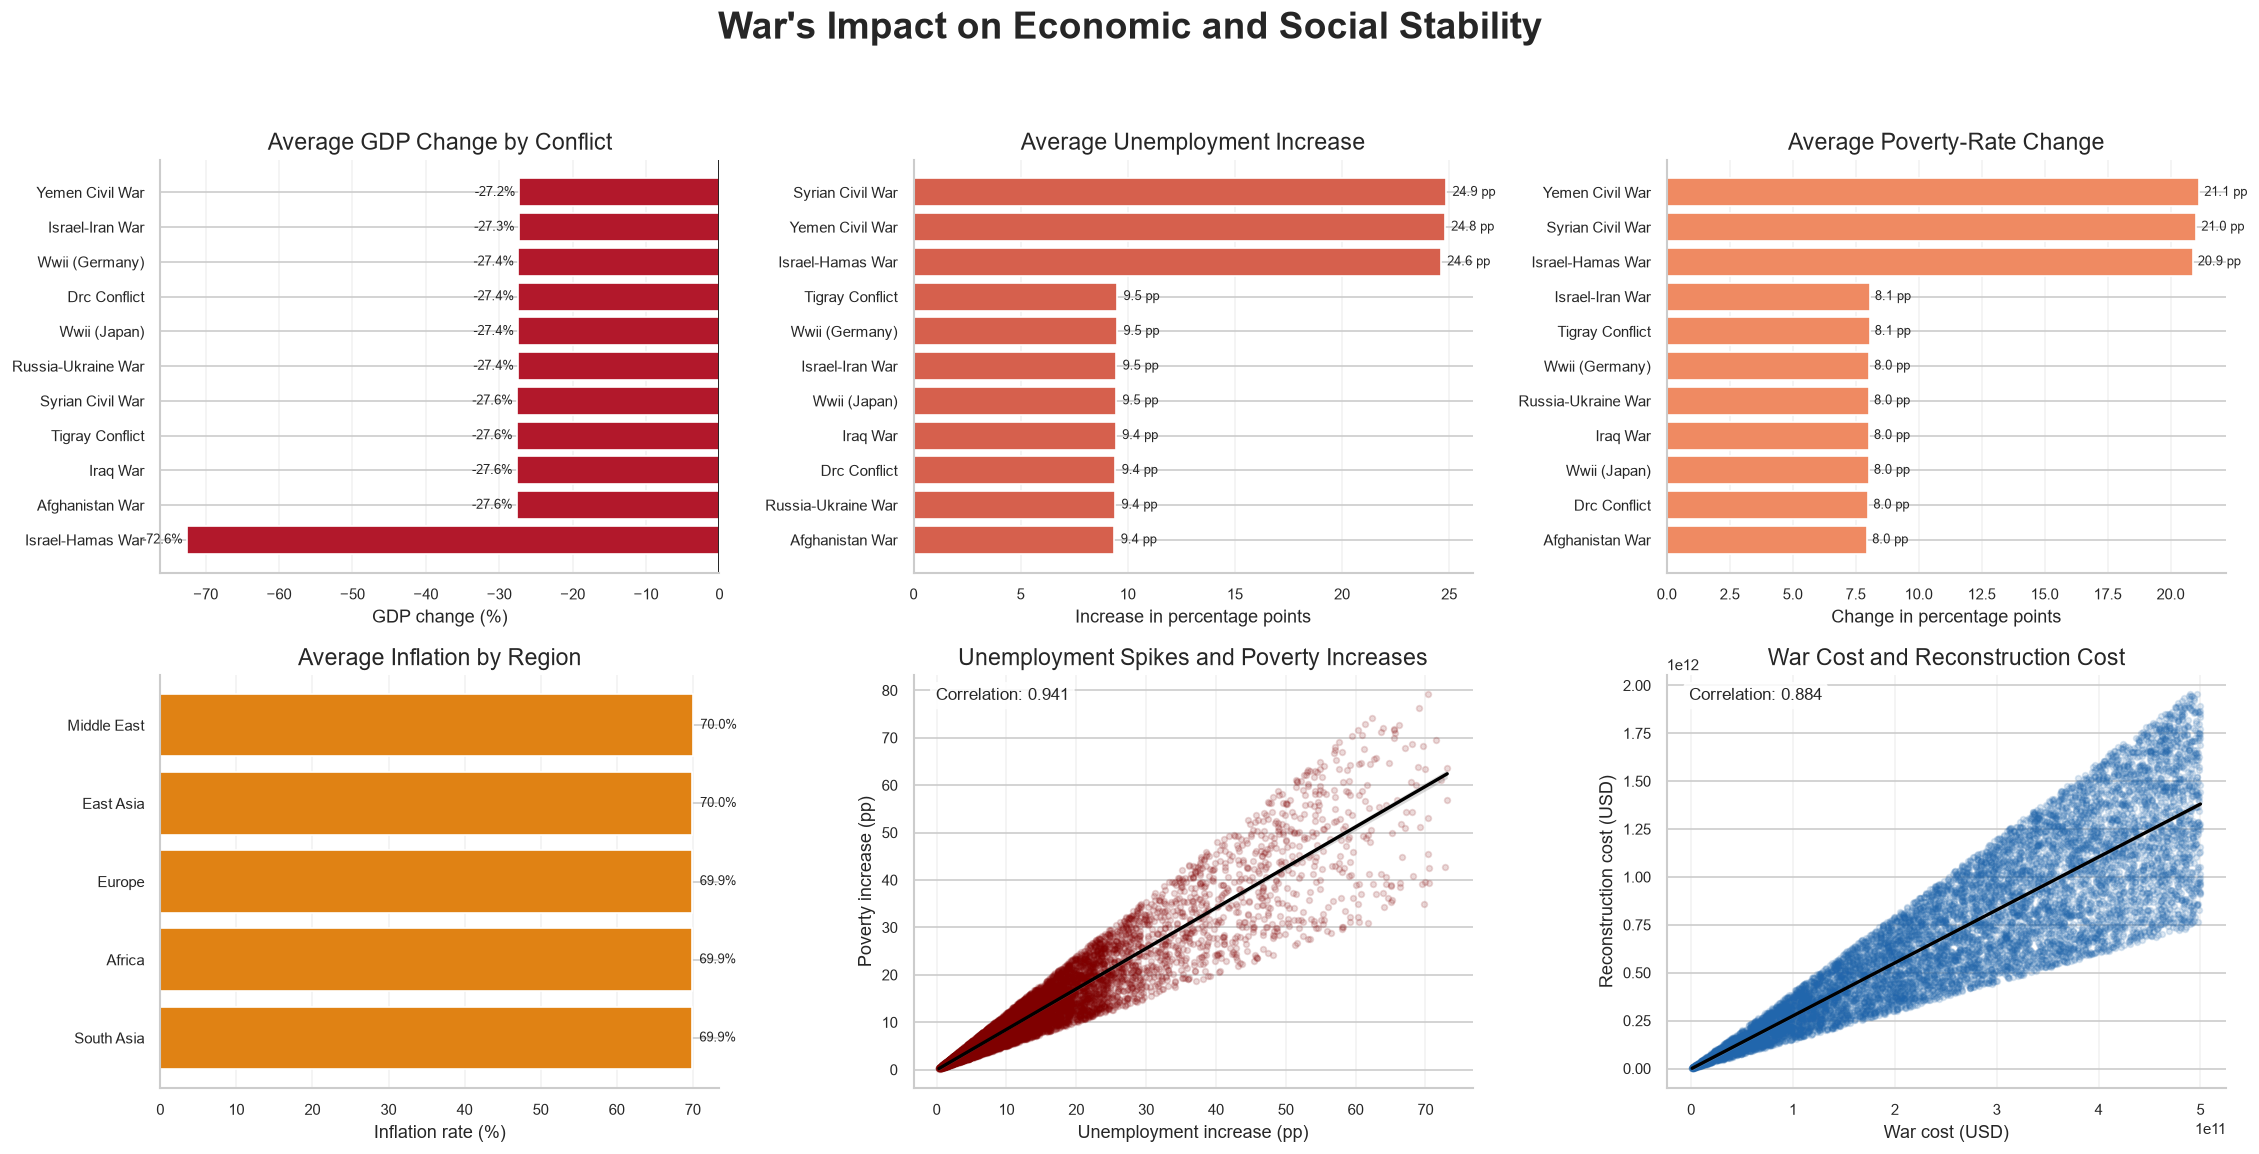


KEY PERFORMANCE INDICATORS
                          Indicator                  Result
                 Average GDP change                 -31.61%
      Average unemployment increase 13.61 percentage points
        Average poverty-rate change 11.56 percentage points
             Average inflation rate                  69.95%
  Average informal-economy increase 26.78 percentage points
War/reconstruction cost correlation                   0.884
   Unemployment/poverty correlation                   0.941

INCREASE / DECREASE REMARKS
• GDP decreased by an average of 31.61% across the observations.
• Unemployment increased by an average of 13.61 percentage points.
• Poverty increased by an average of 11.56 percentage points.
• Informal economic activity increased by an average of 26.78 percentage points.
• The region with the highest average inflation was Middle East at 70.00%.
• The conflict with the largest average GDP decline was Israel-Hamas War at -72.55%.
• The conflict with the larg

In [1]:
# ============================================================
# WAR'S IMPACT ON ECONOMIC AND SOCIAL STABILITY
# Complete analysis, visualization, KPI summary, and conclusion
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

DATA_PATH = Path("war_economic_impact_dataset.csv")
OUTPUT_DIR = Path("war_impact_figures")
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

# ------------------------------------------------------------
# 2. Load and standardize data
# ------------------------------------------------------------

df = pd.read_csv(DATA_PATH)

# Standardize column names
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace("%", "pct", regex=False)
      .str.replace(r"[^a-z0-9]+", "_", regex=True)
      .str.strip("_")
)

# Rename columns to shorter, consistent names
rename_columns = {
    "conflict_name": "conflict",
    "primary_country": "country",

    "pre_war_unemployment_pct": "pre_unemployment",
    "during_war_unemployment_pct": "during_unemployment",
    "unemployment_spike_percentage_points": "unemployment_spike",

    "pre_war_poverty_rate_pct": "pre_poverty",
    "during_war_poverty_rate_pct": "during_poverty",

    "youth_unemployment_change_pct": "youth_unemployment_change",
    "extreme_poverty_rate_pct": "extreme_poverty",
    "food_insecurity_rate_pct": "food_insecurity",
    "households_fallen_into_poverty_estimate": "households_into_poverty",

    "gdp_change_pct": "gdp_change",
    "inflation_rate_pct": "inflation",
    "currency_devaluation_pct": "currency_devaluation",

    "cost_of_war_usd": "war_cost",
    "estimated_reconstruction_cost_usd": "reconstruction_cost",

    "informal_economy_size_pre_war_pct": "informal_pre",
    "informal_economy_size_during_war_pct": "informal_during",

    "currency_black_market_rate_gap_pct": "black_market_rate_gap",
    "black_market_activity_level": "black_market_level",
    "primary_black_market_goods": "black_market_goods",
    "war_profiteering_documented": "war_profiteering",
    "most_affected_sector": "affected_sector",
}

df.rename(
    columns={
        old: new
        for old, new in rename_columns.items()
        if old in df.columns
    },
    inplace=True,
)

# ------------------------------------------------------------
# 3. Clean text and numeric columns
# ------------------------------------------------------------

text_columns = df.select_dtypes(
    include=["object", "string", "category"]
).columns

for column in text_columns:
    df[column] = (
        df[column]
        .astype("string")
        .str.strip()
        .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
        .fillna("Unknown")
    )

# Standardize selected categorical values
for column in [
    "conflict",
    "conflict_type",
    "region",
    "status",
    "country",
    "affected_sector",
]:
    if column in df.columns:
        df[column] = df[column].str.title()

# Only convert genuinely numeric columns.
# black_market_level must remain categorical.
numeric_columns = [
    "start_year",
    "end_year",
    "pre_unemployment",
    "during_unemployment",
    "unemployment_spike",
    "youth_unemployment_change",
    "pre_poverty",
    "during_poverty",
    "extreme_poverty",
    "food_insecurity",
    "households_into_poverty",
    "gdp_change",
    "inflation",
    "currency_devaluation",
    "war_cost",
    "reconstruction_cost",
    "informal_pre",
    "informal_during",
    "black_market_rate_gap",
]

numeric_columns = [
    column for column in numeric_columns
    if column in df.columns
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")
    df[column] = df[column].fillna(df[column].median())

# ------------------------------------------------------------
# 4. Feature engineering
# ------------------------------------------------------------

df["poverty_change"] = (
    df["during_poverty"] - df["pre_poverty"]
)

df["informal_economy_change"] = (
    df["informal_during"] - df["informal_pre"]
)

df["reconstruction_premium"] = (
    (df["reconstruction_cost"] - df["war_cost"])
    / df["war_cost"]
    * 100
)

# ------------------------------------------------------------
# 5. Aggregate data for clear presentation charts
# ------------------------------------------------------------

conflict_summary = (
    df.groupby("conflict", as_index=False)
      .agg(
          observations=("conflict", "size"),
          gdp_change=("gdp_change", "mean"),
          unemployment_spike=("unemployment_spike", "mean"),
          poverty_change=("poverty_change", "mean"),
          inflation=("inflation", "mean"),
          informal_economy_change=(
              "informal_economy_change",
              "mean",
          ),
          war_cost=("war_cost", "mean"),
          reconstruction_cost=("reconstruction_cost", "mean"),
      )
)

region_summary = (
    df.groupby("region", as_index=False)
      .agg(
          gdp_change=("gdp_change", "mean"),
          unemployment_spike=("unemployment_spike", "mean"),
          poverty_change=("poverty_change", "mean"),
          inflation=("inflation", "mean"),
          informal_economy_change=(
              "informal_economy_change",
              "mean",
          ),
      )
)

# ------------------------------------------------------------
# 6. Calculate KPIs
# ------------------------------------------------------------

average_gdp_change = df["gdp_change"].mean()
average_unemployment_spike = df["unemployment_spike"].mean()
average_poverty_change = df["poverty_change"].mean()
average_informal_change = df["informal_economy_change"].mean()
average_inflation = df["inflation"].mean()

worst_gdp = conflict_summary.loc[
    conflict_summary["gdp_change"].idxmin()
]

largest_unemployment = conflict_summary.loc[
    conflict_summary["unemployment_spike"].idxmax()
]

largest_poverty_increase = conflict_summary.loc[
    conflict_summary["poverty_change"].idxmax()
]

highest_inflation_region = region_summary.loc[
    region_summary["inflation"].idxmax()
]

cost_correlation = df[
    ["war_cost", "reconstruction_cost"]
].corr().iloc[0, 1]

poverty_unemployment_correlation = df[
    ["poverty_change", "unemployment_spike"]
].corr().iloc[0, 1]

# ------------------------------------------------------------
# 7. Create presentation-ready visualizations
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(19, 12))
fig.suptitle(
    "War's Impact on Economic and Social Stability",
    fontsize=22,
    fontweight="bold",
    y=0.98,
)

# -------- Chart 1: GDP change --------

plot_data = conflict_summary.sort_values("gdp_change")

colors = [
    "#b2182b" if value < 0 else "#2166ac"
    for value in plot_data["gdp_change"]
]

axes[0, 0].barh(
    plot_data["conflict"],
    plot_data["gdp_change"],
    color=colors,
)

axes[0, 0].axvline(0, color="black", linewidth=1)
axes[0, 0].set_title("Average GDP Change by Conflict")
axes[0, 0].set_xlabel("GDP change (%)")
axes[0, 0].set_ylabel("")

for index, value in enumerate(plot_data["gdp_change"]):
    axes[0, 0].text(
        value - 0.5 if value < 0 else value + 0.5,
        index,
        f"{value:.1f}%",
        va="center",
        ha="right" if value < 0 else "left",
        fontsize=8,
    )

# -------- Chart 2: Unemployment --------

plot_data = conflict_summary.sort_values(
    "unemployment_spike",
    ascending=True,
)

axes[0, 1].barh(
    plot_data["conflict"],
    plot_data["unemployment_spike"],
    color="#d6604d",
)

axes[0, 1].set_title("Average Unemployment Increase")
axes[0, 1].set_xlabel("Increase in percentage points")
axes[0, 1].set_ylabel("")

for index, value in enumerate(plot_data["unemployment_spike"]):
    axes[0, 1].text(
        value + 0.3,
        index,
        f"{value:.1f} pp",
        va="center",
        fontsize=8,
    )

# -------- Chart 3: Poverty change --------

plot_data = conflict_summary.sort_values(
    "poverty_change",
    ascending=True,
)

poverty_colors = [
    "#2166ac" if value < 0 else "#ef8a62"
    for value in plot_data["poverty_change"]
]

axes[0, 2].barh(
    plot_data["conflict"],
    plot_data["poverty_change"],
    color=poverty_colors,
)

axes[0, 2].axvline(0, color="black", linewidth=1)
axes[0, 2].set_title("Average Poverty-Rate Change")
axes[0, 2].set_xlabel("Change in percentage points")
axes[0, 2].set_ylabel("")

for index, value in enumerate(plot_data["poverty_change"]):
    axes[0, 2].text(
        value + 0.2 if value >= 0 else value - 0.2,
        index,
        f"{value:.1f} pp",
        va="center",
        ha="left" if value >= 0 else "right",
        fontsize=8,
    )

# -------- Chart 4: Inflation by region --------

plot_data = region_summary.sort_values(
    "inflation",
    ascending=True,
)

axes[1, 0].barh(
    plot_data["region"],
    plot_data["inflation"],
    color="#e08214",
)

axes[1, 0].set_title("Average Inflation by Region")
axes[1, 0].set_xlabel("Inflation rate (%)")
axes[1, 0].set_ylabel("")

for index, value in enumerate(plot_data["inflation"]):
    axes[1, 0].text(
        value + 1,
        index,
        f"{value:.1f}%",
        va="center",
        fontsize=8,
    )

# -------- Chart 5: Poverty versus unemployment --------

sample_size = min(10_000, len(df))
plot_sample = df.sample(sample_size, random_state=42)

sns.regplot(
    data=plot_sample,
    x="unemployment_spike",
    y="poverty_change",
    scatter_kws={
        "alpha": 0.15,
        "s": 12,
        "color": "#7f0000",
    },
    line_kws={
        "color": "black",
        "linewidth": 2,
    },
    ax=axes[1, 1],
)

axes[1, 1].set_title(
    "Unemployment Spikes and Poverty Increases"
)
axes[1, 1].set_xlabel("Unemployment increase (pp)")
axes[1, 1].set_ylabel("Poverty increase (pp)")

axes[1, 1].text(
    0.04,
    0.94,
    f"Correlation: {poverty_unemployment_correlation:.3f}",
    transform=axes[1, 1].transAxes,
    fontsize=10,
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.85,
    ),
)

# -------- Chart 6: War cost versus reconstruction cost --------

cost_sample = df.sample(sample_size, random_state=42)

sns.regplot(
    data=cost_sample,
    x="war_cost",
    y="reconstruction_cost",
    scatter_kws={
        "alpha": 0.15,
        "s": 12,
        "color": "#2166ac",
    },
    line_kws={
        "color": "black",
        "linewidth": 2,
    },
    ax=axes[1, 2],
)

axes[1, 2].set_title(
    "War Cost and Reconstruction Cost"
)
axes[1, 2].set_xlabel("War cost (USD)")
axes[1, 2].set_ylabel("Reconstruction cost (USD)")

axes[1, 2].ticklabel_format(
    style="sci",
    axis="both",
    scilimits=(0, 0),
)

axes[1, 2].text(
    0.04,
    0.94,
    f"Correlation: {cost_correlation:.3f}",
    transform=axes[1, 2].transAxes,
    fontsize=10,
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.85,
    ),
)

# Improve layout
for ax in axes.flat:
    ax.grid(axis="x", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout(rect=[0, 0.18, 1, 0.95])

# Save and display the figure
plt.savefig(
    OUTPUT_DIR / "war_economic_social_impact_dashboard.png",
    bbox_inches="tight",
)

plt.show()

# ------------------------------------------------------------
# 8. KPI summary table
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("KEY PERFORMANCE INDICATORS")
print("=" * 80)

kpi_table = pd.DataFrame({
    "Indicator": [
        "Average GDP change",
        "Average unemployment increase",
        "Average poverty-rate change",
        "Average inflation rate",
        "Average informal-economy increase",
        "War/reconstruction cost correlation",
        "Unemployment/poverty correlation",
    ],
    "Result": [
        f"{average_gdp_change:.2f}%",
        f"{average_unemployment_spike:.2f} percentage points",
        f"{average_poverty_change:.2f} percentage points",
        f"{average_inflation:.2f}%",
        f"{average_informal_change:.2f} percentage points",
        f"{cost_correlation:.3f}",
        f"{poverty_unemployment_correlation:.3f}",
    ],
})

print(kpi_table.to_string(index=False))

# ------------------------------------------------------------
# 9. Increase/decrease remarks
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("INCREASE / DECREASE REMARKS")
print("=" * 80)

print(
    f"• GDP decreased by an average of "
    f"{abs(average_gdp_change):.2f}% across the observations."
)

print(
    f"• Unemployment increased by an average of "
    f"{average_unemployment_spike:.2f} percentage points."
)

print(
    f"• Poverty increased by an average of "
    f"{average_poverty_change:.2f} percentage points."
)

print(
    f"• Informal economic activity increased by an average of "
    f"{average_informal_change:.2f} percentage points."
)

print(
    f"• The region with the highest average inflation was "
    f"{highest_inflation_region['region']} at "
    f"{highest_inflation_region['inflation']:.2f}%."
)

print(
    f"• The conflict with the largest average GDP decline was "
    f"{worst_gdp['conflict']} at "
    f"{worst_gdp['gdp_change']:.2f}%."
)

print(
    f"• The conflict with the largest average unemployment increase was "
    f"{largest_unemployment['conflict']} at "
    f"{largest_unemployment['unemployment_spike']:.2f} percentage points."
)

print(
    f"• The conflict with the largest average poverty increase was "
    f"{largest_poverty_increase['conflict']} at "
    f"{largest_poverty_increase['poverty_change']:.2f} percentage points."
)

# ------------------------------------------------------------
# 10. Executive summary at the bottom
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EXECUTIVE SUMMARY")
print("=" * 80)

print(
    f"""
This analysis examined {len(df):,} observations across
{df['conflict'].nunique()} conflicts and {df['region'].nunique()} regions.

The results show that conflict is associated with broad economic and social
pressure. GDP declined by an average of {abs(average_gdp_change):.2f}%,
while unemployment increased by {average_unemployment_spike:.2f} percentage
points. Poverty increased by {average_poverty_change:.2f} percentage points,
and informal economic activity increased by
{average_informal_change:.2f} percentage points.

{highest_inflation_region['region']} recorded the highest average inflation
rate at {highest_inflation_region['inflation']:.2f}%.

The correlation between war costs and reconstruction costs was
{cost_correlation:.3f}, indicating that more expensive conflicts tend to
require greater reconstruction investment. The strongest social relationship
was between unemployment increases and poverty increases, with a correlation
of {poverty_unemployment_correlation:.3f}.

Overall, the findings suggest that conflict affects economies through several
connected channels: reduced output, unemployment, rising prices, poverty,
currency instability, and expansion of informal economic activity.

These results are descriptive associations and should not be interpreted as
proof of causation. The dataset contains many observations but relatively few
named conflicts, and repeated or simulated observations may influence the
reported averages and correlations.
"""
)

print(f"Figures saved in: {OUTPUT_DIR.resolve()}")